In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

In [5]:
df = pd.read_csv('/content/loan_data.csv')

In [6]:
target='loan_paid_back'
X=df.drop(columns=[target,'id'])
y=df[target]

In [7]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

In [8]:
numeric_transformer=Pipeline([('scaler',StandardScaler())])
categorical_transformer=Pipeline([('encoder',OneHotEncoder(handle_unknown='ignore'))])

preprocessor=ColumnTransformer([
    ('num',numeric_transformer,numeric_cols),
    ('cat',categorical_transformer,categorical_cols)
])

In [9]:
clf=Pipeline([
    ('preprocess',preprocessor),
    ('model',LogisticRegression(max_iter=500))
])

In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
clf.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['annual_income',
                                                   'debt_to_income_ratio',
                                                   'credit_score',
                                                   'loan_amount',
                                                   'interest_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'marital_status',
                                                   'education_level',
                                                   'employment_status',
                                                   'loan_purpose',
                                                   'grade_subgrade'])])),
                ('model', LogisticRegression(max_iter=500))])

In [12]:
y_pred_proba_series=pd.Series(clf.predict_proba(X_test)[:,1], index=X_test.index)


In [13]:
auc=roc_auc_score(y_test,y_pred_proba_series)


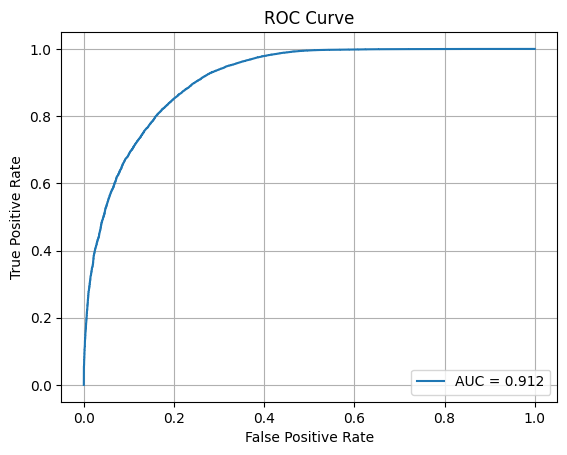

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_series)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig('/content/roc_curve.png')

roc_data = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr
})
roc_data.to_csv('/content/roc_curve.csv', index=False)

In [19]:
subgroup_results={}


In [20]:
for level in df['education_level'].unique():
    idx = X_test[X_test['education_level']==level].index
    if len(idx)>1:
        auc_level = roc_auc_score(y_test.loc[idx], y_pred_proba_series.loc[idx])
        subgroup_results[f"education_{level}"]=auc_level


In [21]:
purpose_auc={}
for purpose in df['loan_purpose'].unique():
    idx = X_test[X_test['loan_purpose']==purpose].index
    if len(idx)>1:
        purpose_auc[purpose]=roc_auc_score(y_test.loc[idx],
                                           y_pred_proba_series.loc[idx])

In [22]:
top3=dict(sorted(purpose_auc.items(),key=lambda x: x[1],reverse=True)[:3])
bottom3=dict(sorted(purpose_auc.items(),key=lambda x: x[1])[:3])

print("Education AUCs:", subgroup_results)
print("Top 3 Loan Purposes:", top3)
print("Bottom 3 Loan Purposes:", bottom3)
print("Overall AUC:", auc)

Education AUCs: {'education_High School': np.float64(0.9106703175466955), "education_Master's": np.float64(0.9084253985583735), "education_Bachelor's": np.float64(0.9124162018370803), 'education_PhD': np.float64(0.9084425939050318), 'education_Other': np.float64(0.924746080963119)}
Top 3 Loan Purposes: {'Education': np.float64(0.9233193402363427), 'Vacation': np.float64(0.9191458333333333), 'Medical': np.float64(0.918354811717659)}
Bottom 3 Loan Purposes: {'Car': np.float64(0.9008508610803224), 'Debt consolidation': np.float64(0.9114168579918226), 'Other': np.float64(0.9115254132672372)}
Overall AUC: <function auc at 0x7a1ba9deef20>
